## **From Deterministic to Stochastic Portfolio Optimization**


# Linear Optimization

The objective is to minimize the absolute portfolio risk while achieving a target return, using the MAD risk metric (Mean Absolute Deviation).  

$(1)$ Min Linear Risk
$(2)$ Subject to :
	The portfolio is entirely composed of the chosen assets.
	The portfolio's return is greater or equal that the target return.
$$\text{We have } (1) \quad \iff \quad \text{min } MAD = \frac{1}{T} \sum_{t=1}^{T} \big| R_{p,t} - \mu_p \big| $$We need to linearize it by using these auxiliary variables :  $$\forall t\in [1, T], \quad z_t \geq  \big|R_{p,t} - \mu_p\big| \Longrightarrow \left\{ \begin{array}{ll} z_t \geq  R_{p,t} - \mu_p \\ z_t \geq  - (R_{p,t} - \mu_p) \end{array} \right.$$Thus :$$ \text{min } MAD = \frac{1}{T} \sum_{t=1}^{T} \big| R_{p,t} - \mu_p \big| \quad \iff \quad \text{min }\frac{1}{T}\sum_{t=1}^{T} z_t $$
$$\text{And } (2) \iff \left\{ \begin{array}{ll} \sum_{i=1}^n w_i = 1 & \\ \mu_p \ge \mu_{\text{target}} \end{array} \right.$$
Thus, the linearized version of our problem is : 
$$\text{min } \frac{1}{T} \sum_{t=1}^{T} z_t$$
$$\text{s.t. } \begin{cases} \sum_{i=1}^n w_i = 1 \\ \mu_p \ge \mu_{\text{target}} \\ z_t \geq R_{p,t} - \mu_p, \quad \forall t\in [1, T] \\ z_t \geq \mu_p - R_{p,t}, \quad \forall t\in [1, T] \\ \mu_{\text{target}} \geq 0 \end{cases}$$
# Integer Programming for Constraints

Same as before and we add the following constraint :

* Use a maximum of $K$ assets.

The logic is going to be as follows : 

* If asset $A_i$ is selected, then $w_i^{min} \leq w_i \le w_i^{max}$
* If asset $A_i$ is not selected, then $w_i = 0$

To formulate this, we need  $y_i = \left\{ \begin{array}{ll} 1 & \text{if } A_i \text{ is selected} \\ 0 & \text{otherwise} \end{array} \right.$  and  $w_i^{min}, w_i^{max}$.

Which gives us : 
$$\left\{ \begin{array}{lll}  \sum_{i} y_i \le K  \\ y_i \cdot w_i^{min} \leq w_i \le y_i \cdot w_i^{max}   \\\\ y_i \in \{0, 1\}\\ w_i, w_i^{min}, w_i^{max} \geq 0\end{array} \\\right.$$

# Sensitivity Analysis

To observe the relationship between the target return and the risk, we calculate the $\text{Min MAD}$ for $n$ different target returns and plot the evolution of the risk based on target return. This is known as the "efficient frontier".

Then, we want to quantify the quality of both our models. To do this, we analyze the sensibility of asset weights based on target return. 

In practice, we measure the average asset weight variation between two optimal solutions using : $$s = \frac{1}{P-1}\sum_{p=1}^{P-1} \left(\sum_{i=1}^n|w_{i,p+1} - w_{i,p}|\right)$$Finally, we verify that our optimal solutions $w_i$ do not depend too much on the specificity of our historic sample. To do that apply the following Bootstrap process. 

We create artificial return samples from our historic sample. Intuitively, these new return samples are formed by picking returns at random and with replacement from the historic sample.

Formally, we create $B \ge 1$ samples $S_b = \{R_{b,1}, R_{b,2}, ... , R_{b,T}\}$ such that $R_{b, j} \in R$, $\forall b, j \in \left[\!\left[ 1, B \right]\!\right] \times \left[\!\left[ 1, T \right]\!\right]$, where $R = \{R_1, R_2, ... , R_T\}$ are the returns from the historic sample.

Then, we are able to measure the dependence by using the variance of the optimal weigth $w_{b,i}$ from these artificial samples. 
In the end, for each asset $i$, we have : $$\sigma_{w_i} = \sqrt{ \frac{1}{B-1} \sum_{b=1}^B (w_{b,i} - \bar{w}_i)^2} = \sqrt{ \frac{1}{B-1} \sum_{b=1}^B (w_{b,i} - \underbrace{\frac{1}{B}\sum_{k=1}^B w_{k,i}}_{\bar{w}_i})^2}$$A weak $\sigma_{w_i}$ indicates a robust optimal weight $w_i$ for the $i$  asset. 
Whereas a bigger $\sigma_{w_i}$ suggests an unstable optimal weight for the $i$ asset with strong dependence to the historic sample, indicating an increased risk of overfitting.

## Assets used

* SPX : S&P 500 Index
* JPM : JPMorgan Chase
* XOM : Exxon Mobil
* WMT : Walmart
* TSLA : Tesla
* UNH : UnitedHealth Group
* V : Visa
* NVDA : NVIDIA
* DIS : Walt Disney
* EFA : ETF MSCI EAFE (Europe, Asie, Extrême-Orient)
* VWO : ETF Vanguard Emerging Markets
* TM : Toyota Motor Corp.
* GLD : ETF SPDR Gold Shares
* USO : ETF United States Oil Fund
* BND : ETF Vanguard Total Bond Market
* VNQ : ETF Vanguard Real Estate
* UUP : Invesco DB US Dollar Index Bullish Fund

### 1. Linear Portfolio Optimization

In [4]:
import pandas as pd
import numpy as np
import pulp as pl
from typing import Dict, Optional



def compute_mad(returns: pd.DataFrame, w: np.ndarray) -> float:
    """
    Computes the Mean Average Deviation of the portfolio.

    Args : 
        returns (DataFrame) : all the returns from the assets.
        w (ndarray) : weights of the assets.
    
    Returns : 
        Mean Average Deviation of the portfolio.    
    """
    w = np.array(w)
        
    portfolio_returns = returns.values.dot(w)
    mean_return = portfolio_returns.mean()
    mad = np.mean(np.abs(portfolio_returns - mean_return))

    return mad

def optimize_mad_lp(returns: pd.DataFrame, target_return: float, lower_bounds: Optional[Dict[str, float]] = None, upper_bounds: Optional[Dict[str, float]] = None, allow_short: bool = False) -> Dict[str, float]:
    """
    This solves the linearized version of our problem. 
    
    Args:
        returns (DataFrame) : all the returns from the assets.
        target_return (float) : the minimum return we aim for.
        lower_bounds (Optional[Dict[str, float]]) : minimum weight per asset.
        upper_bounds (Optional[Dict[str, float]]) : maximum weight per asset.
        allow_short (bool) : True if we want to be able to short, False otherwise. 
        
    Returns:
        Dictionnary of optimal weights per asset -> {asset: weight}.
    """

    assets = list(returns.columns)
    T = len(returns)
    objective_function = pl.LpProblem("lp_portfolio_optimization", pl.LpMinimize)
    low_bound_w = None if allow_short else 0
    
    # Decision variables
    w = pl.LpVariable.dicts("w", assets, lowBound=low_bound_w)
    z = pl.LpVariable.dicts("z", list(range(T)), lowBound=0)
    mu_p = pl.LpVariable("mu_p")

    # Objective function
    objective_function += (1.0 / T) * pl.lpSum([z[i] for i in range(T)]), "objective_function"


    # --- CONSTRAINTS ---

    # mu_p
    mean_asset_returns = returns.mean(axis=0)
    objective_function += mu_p == pl.lpSum([mean_asset_returns[a] * w[a] for a in assets]), "mean_portfolio_return"

    # mad linearization
    for t, (_, return_values) in enumerate(returns.iterrows()):
        
        # R_p_t
        R_p_t = pl.lpSum([return_values[asset] * w[asset] for asset in assets])  
        
        # z_t : positive case
        objective_function += z[t] >= R_p_t - mu_p, f"mad_linearization_positive_case_{t}"
        
        # z_t : negative case
        objective_function += z[t] >= mu_p - R_p_t, f"mad_linearization_negative_case_{t}"

    # sum of weigths = 1
    objective_function += pl.lpSum([w[a] for a in assets]) == 1, "sum_of_weigths"
    
    # target return
    objective_function += mu_p >= target_return, "target_return"
    
    # min weigth
    if lower_bounds:
        for i, lower_bound in lower_bounds.items():
            if lower_bound < 0 and not allow_short:
                raise ValueError(f"Your lower bound '{lower_bound}' is negative. Shorting is not allowed here.")
            objective_function += w[i] >= lower_bound, f"lower_bound_{i}"
            
    # max weight
    if upper_bounds:
        for i, upper_bound in upper_bounds.items():
            objective_function += w[i] <= upper_bound, f"upper_bound_{i}"


    # Solve
    objective_function.solve(pl.PULP_CBC_CMD(msg=False))
    status: str = pl.LpStatus[objective_function.status]

    if status != "Optimal":
        print(f"Warning ! Infeasible (status: {status}) for {target_return:.4f}.")
        return {a: 0.0 for a in assets}

    # optimal weights
    w_vals: Dict[str, float] = {
        a: w[a].value() if w[a].value() is not None else 0.0 
        for a in assets
    }
    
    return w_vals

def compute_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Computes daily returns from prices.

    Args : 
        prices (DataFrame) : prices of the assets.
    
    Returns : 
        Dataframe of daily returns for each asset.
    """
    return prices.pct_change().dropna(how="all")

def clean_asset_file(file_path: str, ticker: str, parse_dates: bool = True, dayfirst: bool = True) -> pd.DataFrame:
    """
    Load an asset CSV file and clean it.

    Args : 
        file_path (str) : path of the CSV file.
        ticker (str) : ticker of the asset.
        parse_dates (bool) : True if should convert date column in datetime.
        dayfirst (bool) : True if DD/MM/YY, False otherwise.

    Returns : 
        Cleaned CSV file of dates/prices for the asset.
    """

    try:
        df = pd.read_csv(file_path, sep=None, engine="python", encoding="utf-8-sig", parse_dates=["Date"] if parse_dates else None, dayfirst=dayfirst)
    except FileNotFoundError:
        print(f"File {file_path} wasn't found.")
        return pd.DataFrame()
    except Exception as e:
        print(f"Error downloadinf {file_path} : {e}")
        return pd.DataFrame()

    price_col = df.columns[1] 
    df = df[["Date", price_col]].rename(columns={price_col: ticker})
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=dayfirst, errors='coerce')
    df = df.dropna(subset=["Date"])
    df = df.set_index("Date").sort_index()

    return df

def align_and_merge_prices(price_dfs: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Merge and align asset price DataFrames.

    Args : 
        prices (Dict[str, pd.DataFrame]) : prices for each asset.

    Returns :    
        Merged and aligned asset price DataFrames.
    """
    
    if not price_dfs:
        return pd.DataFrame()

    first_ticker = next(iter(price_dfs))
    merged_df = price_dfs[first_ticker].reset_index().sort_values("Date")
    
    for ticker, ticker_df in price_dfs.items():
        if ticker != first_ticker:
            ticker_df = ticker_df.reset_index().sort_values("Date")
            merged_df = pd.merge_asof(merged_df, ticker_df, on="Date", direction="nearest", tolerance=pd.Timedelta(days=3))

    prices = merged_df.set_index("Date")
    prices = prices.dropna(how='any').sort_index() 

    return prices



if __name__ == "__main__":

    BASE_PATH = r"C:\Users\romsc\OneDrive - De Vinci\UVic\Courses\Optimization\Portfolio_Optimization"
    ASSETS = ["SPX", "AAPL", "MSFT", "GOOG", "JPM", "XOM", "WMT", "TSLA", "UNH", "V", "NVDA", "DIS", "EFA", "VWO", "TM", "GLD", "USO", "BND", "VNQ", "UUP"]

    dfs = {}
    for ticker in ASSETS:
        file_path = f"{BASE_PATH}\\{ticker}.csv"
        
        df = clean_asset_file(file_path, ticker)
        dfs[ticker] = df


    if len(dfs) != len(ASSETS):
        print("Error : Couldn't load 1 df per asset...")
        
    else:
        
        prices = align_and_merge_prices(dfs)
        returns = compute_returns(prices)

        TARGET_RETURN = 0.05 / 100
        ALLOW_SHORT = False

        
        print(f"\nOptimizing MAD to achieve a {TARGET_RETURN:.4f}% return...")
        weights: Dict[str, float] = optimize_mad_lp(returns=returns, target_return=TARGET_RETURN, allow_short=ALLOW_SHORT)

        print("\n--- Optimal portfolio weights ---\n")
        for asset, w in weights.items():
            print(f"* {asset} : {w:.4f}")

            
        w = np.array([weights.get(a, 0.0) for a in returns.columns])
        expected_return = returns.mean().values.dot(w)
        mad = compute_mad(returns, w)

        print("\n--- Optimal portfolio metrics ---\n")
        print(f"* Expected return = {expected_return:.6f} (target = {TARGET_RETURN:.6f})")
        print(f"* MAD = {mad:.6f}\n")





Optimizing MAD to achieve a 0.0005% return...

--- Optimal portfolio weights ---

* SPX : 0.0103
* AAPL : 0.0090
* MSFT : 0.0003
* GOOG : 0.0000
* JPM : 0.0287
* XOM : 0.0096
* WMT : 0.0247
* TSLA : 0.0029
* UNH : 0.0223
* V : 0.0149
* NVDA : 0.0078
* DIS : 0.0000
* EFA : 0.0134
* VWO : 0.0000
* TM : 0.0000
* GLD : 0.0676
* USO : 0.0026
* BND : 0.4440
* VNQ : 0.0000
* UUP : 0.3420

--- Optimal portfolio metrics ---

* Expected return = 0.000500 (target = 0.000500)
* MAD = 0.001964



### 2. Integer Programming for Constraints

In [5]:
import pandas as pd
import numpy as np
import pulp as pl
from typing import Dict, Optional


def compute_mad(returns: pd.DataFrame, w: np.ndarray) -> float:
    """
    Computes the Mean Average Deviation of the portfolio.

    Args : 
        returns (DataFrame) : all the returns from the assets.
        w (ndarray) : weights of the assets.
    
    Returns : 
        Mean Average Deviation of the portfolio.    
    """
    w = np.array(w)
        
    portfolio_returns = returns.values.dot(w)
    mean_return = portfolio_returns.mean()
    mad = np.mean(np.abs(portfolio_returns - mean_return))

    return mad

def optimize_mad_lp(returns: pd.DataFrame, target_return: float, lower_bounds: Optional[Dict[str, float]] = None, upper_bounds: Optional[Dict[str, float]] = None, allow_short: bool = False) -> Dict[str, float]:
    """
    This solves the linearized version of our problem. 
    
    Args:
        returns (DataFrame) : all the returns from the assets.
        target_return (float) : the minimum return we aim for.
        lower_bounds (Optional[Dict[str, float]]) : minimum weight per asset.
        upper_bounds (Optional[Dict[str, float]]) : maximum weight per asset.
        allow_short (bool) : True if we want to be able to short, False otherwise. 
        
    Returns:
        Dictionnary of optimal weights per asset -> {asset: weight}.
    """

    assets = list(returns.columns)
    T = len(returns)
    objective_function = pl.LpProblem("linear_portfolio_optimization", pl.LpMinimize)
    low_bound_w = None if allow_short else 0
    
    # Decision variables
    w = pl.LpVariable.dicts("w", assets, lowBound=low_bound_w)
    z = pl.LpVariable.dicts("z", list(range(T)), lowBound=0)
    mu_p = pl.LpVariable("mu_p")

    # Objective function
    objective_function += (1.0 / T) * pl.lpSum([z[i] for i in range(T)]), "objective_function"


    # --- CONSTRAINTS ---

    # mu_p
    mean_asset_returns = returns.mean(axis=0)
    objective_function += mu_p == pl.lpSum([mean_asset_returns[a] * w[a] for a in assets]), "mean_portfolio_return"

    # mad linearization
    for t, (_, return_values) in enumerate(returns.iterrows()):
        
        # R_p_t
        R_p_t = pl.lpSum([return_values[asset] * w[asset] for asset in assets])  
        
        # z_t : positive case
        objective_function += z[t] >= R_p_t - mu_p, f"mad_linearization_positive_case_{t}"
        
        # z_t : negative case
        objective_function += z[t] >= mu_p - R_p_t, f"mad_linearization_negative_case_{t}"

    # sum of weigths = 1
    objective_function += pl.lpSum([w[a] for a in assets]) == 1, "sum_of_weigths"
    
    # target return
    objective_function += mu_p >= target_return, "target_return"
    
    # min weigth
    if lower_bounds:
        for i, lower_bound in lower_bounds.items():
            if lower_bound < 0 and not allow_short:
                raise ValueError(f"Your lower bound '{lower_bound}' is negative. Shorting is not allowed here.")
            objective_function += w[i] >= lower_bound, f"lower_bound_{i}"
            
    # max weight
    if upper_bounds:
        for i, upper_bound in upper_bounds.items():
            objective_function += w[i] <= upper_bound, f"upper_bound_{i}"


    # solve
    objective_function.solve(pl.PULP_CBC_CMD(msg=False))
    status: str = pl.LpStatus[objective_function.status]

    if status != "Optimal":
        print(f"Warning ! Infeasible (status: {status}) for {target_return:.4f}.")
        return {a: 0.0 for a in assets}

    # optimal weights
    w_vals: Dict[str, float] = {
        a: w[a].value() if w[a].value() is not None else 0.0 
        for a in assets
    }
    
    return w_vals

def compute_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Computes daily returns from prices.

    Args : 
        prices (DataFrame) : prices of the assets.
    
    Returns : 
        Dataframe of daily returns for each asset.
    """
    return prices.pct_change().dropna(how="all")

def clean_asset_file(file_path: str, ticker: str, parse_dates: bool = True, dayfirst: bool = True) -> pd.DataFrame:
    """
    Load an asset CSV file and clean it.

    Args : 
        file_path (str) : path of the CSV file.
        ticker (str) : ticker of the asset.
        parse_dates (bool) : True if should convert date column in datetime.
        dayfirst (bool) : True if DD/MM/YY, False otherwise.

    Returns : 
        Cleaned CSV file of dates/prices for the asset.
    """

    try:
        df = pd.read_csv(file_path, sep=None, engine="python", encoding="utf-8-sig", parse_dates=["Date"] if parse_dates else None, dayfirst=dayfirst)
    except FileNotFoundError:
        print(f"File {file_path} wasn't found.")
        return pd.DataFrame()
    except Exception as e:
        print(f"Error downloadinf {file_path} : {e}")
        return pd.DataFrame()

    price_col = df.columns[1] 
    df = df[["Date", price_col]].rename(columns={price_col: ticker})
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=dayfirst, errors='coerce')
    df = df.dropna(subset=["Date"])
    df = df.set_index("Date").sort_index()

    return df

def align_and_merge_prices(price_dfs: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Merge and align asset price DataFrames.

    Args : 
        prices (Dict[str, pd.DataFrame]) : prices for each asset.

    Returns :    
        Merged and aligned asset price DataFrames.
    """
    
    if not price_dfs:
        return pd.DataFrame()

    first_ticker = next(iter(price_dfs))
    merged_df = price_dfs[first_ticker].reset_index().sort_values("Date")
    
    for ticker, ticker_df in price_dfs.items():
        if ticker != first_ticker:
            ticker_df = ticker_df.reset_index().sort_values("Date")
            merged_df = pd.merge_asof(merged_df, ticker_df, on="Date", direction="nearest", tolerance=pd.Timedelta(days=3))

    prices = merged_df.set_index("Date")
    prices = prices.dropna(how='any').sort_index() 

    return prices

# New function
def optimize_mad_milp(returns: pd.DataFrame, target_return: float, K: int = 3, lower_bound: float = 0.01, upper_bound: float = 0.5, allow_short: bool = False) -> Dict[str, float]:
    """
    This solves the new problem using MILP. 
    
    Args:
        returns (DataFrame) : all the returns from the assets.
        target_return (float) : the minimum return we aim for.
        lower_bound (float) : minimum weight for an asset.
        upper_bound (float]) : maximum weight for an asset.
        allow_short (bool) : True if we want to be able to short, False otherwise. 
        
    Returns:
        Dictionnary of optimal weights per asset -> {asset: weight}.
    """
    
    assets = list(returns.columns)
    T = len(returns)
    
    objective_function = pl.LpProblem("milp_portfolio_optimization", pl.LpMinimize)
    
    # Decision variables
    w = pl.LpVariable.dicts("w", assets, lowBound=None if allow_short else 0)
    z = pl.LpVariable.dicts("z", list(range(T)), lowBound=0)
    y = pl.LpVariable.dicts("y", assets, cat="Binary")  
    mu_p = pl.LpVariable("mu_p", lowBound=None)
    
    # Objective function
    objective_function += (1.0 / T) * pl.lpSum([z[t] for t in range(T)]), "MAD_obj"


    # --- CONSTRAINTS ---

    # mu_p
    mean_asset_returns = returns.mean()
    objective_function += mu_p == pl.lpSum([mean_asset_returns[a] * w[a] for a in assets]), "mu_def"
    
    # mad linearization
    for t, (_, return_values) in enumerate(returns.iterrows()):

        # R_p_t
        R_p_t = pl.lpSum([return_values[a] * w[a] for a in assets])

        # z_t : positive case
        objective_function += z[t] >= R_p_t - mu_p

        # z_t : negative case
        objective_function += z[t] >= mu_p - R_p_t
    
    # target return
    objective_function += mu_p >= target_return, "target_return"
    
    # sum of weights
    objective_function += pl.lpSum([w[a] for a in assets]) == 1, "sum_of_weights"
    
    # max weigth, min weigth
    for a in assets:
        objective_function += w[a] <= upper_bound * y[a]
        objective_function += w[a] >= lower_bound * y[a]
    
    # cardinality
    objective_function += pl.lpSum([y[a] for a in assets]) <= K, "cardinality"
    
    # Solve
    objective_function.solve(pl.PULP_CBC_CMD(msg=False))
    
    # optimal weights
    w = {a: w[a].value() if w[a].value() else 0.0 for a in assets}
    y = {a: y[a].value() for a in assets}
    
    print(f"The optimal portfolio uses {int(sum(y.values()))} assets (≤ K={K})\n")
    
    return w



if __name__ == "__main__":

    BASE_PATH = r"C:\Users\romsc\OneDrive - De Vinci\UVic\Courses\Optimization\Portfolio_Optimization"
    ASSETS = ["SPX", "AAPL", "MSFT", "GOOG", "JPM", "XOM", "WMT", "TSLA", "UNH", "V", "NVDA", "DIS", "EFA", "VWO", "TM", "GLD", "USO", "BND", "VNQ", "UUP"]

    dfs = {}
    for ticker in ASSETS:
        file_path = f"{BASE_PATH}\\{ticker}.csv"
        
        df = clean_asset_file(file_path, ticker)
        dfs[ticker] = df


    if len(dfs) != len(ASSETS):
        print("Error : Couldn't load 1 df per asset...")
        
    else:
        
        prices = align_and_merge_prices(dfs)
        returns = compute_returns(prices)

        TARGET_RETURN = 0.05 / 100
        ALLOW_SHORT = False
        

        print(f"\nOptimizing MAD to achieve a {TARGET_RETURN:.4f}% return...")
        weights: Dict[str, float] = optimize_mad_lp(returns=returns, target_return=TARGET_RETURN, allow_short=ALLOW_SHORT)

        print("\n--- Optimal portfolio weights (LP) ---\n")
        for asset, w in weights.items():
            print(f"* {asset} : {w:.4f}")

            
        w = np.array([weights.get(a, 0.0) for a in returns.columns])
        expected_return = returns.mean().values.dot(w)
        mad = compute_mad(returns, w)

        print("\n--- Optimal portfolio metrics (LP) ---\n")
        print(f"* Expected return = {expected_return:.6f} (target = {TARGET_RETURN:.6f})")
        print(f"* MAD = {mad:.6f}\n")


        print("-"*50)
        print("\n--- Optimal portfolio weights (MILP) ---\n")

        K = 3                
        lower_bound = 0.05   
        upper_bound = 0.7   

        w_milp = optimize_mad_milp(returns, target_return=TARGET_RETURN, K=K, lower_bound=lower_bound, upper_bound=upper_bound, allow_short=ALLOW_SHORT)

        for asset, w in w_milp.items():
            print(f"* {asset} : {w:.4f}")


        w = [w_milp[a] for a in returns.columns]
        expected_return_milp = returns.mean().values @ w
        mad_milp = compute_mad(returns, w)

        print("\n--- Optimal portfolio metrics (MILP) ---\n")
        print(f"* Expected return = {expected_return_milp:.6f}")
        print(f"* MAD = {mad_milp:.6f}\n")





Optimizing MAD to achieve a 0.0005% return...

--- Optimal portfolio weights (LP) ---

* SPX : 0.0103
* AAPL : 0.0090
* MSFT : 0.0003
* GOOG : 0.0000
* JPM : 0.0287
* XOM : 0.0096
* WMT : 0.0247
* TSLA : 0.0029
* UNH : 0.0223
* V : 0.0149
* NVDA : 0.0078
* DIS : 0.0000
* EFA : 0.0134
* VWO : 0.0000
* TM : 0.0000
* GLD : 0.0676
* USO : 0.0026
* BND : 0.4440
* VNQ : 0.0000
* UUP : 0.3420

--- Optimal portfolio metrics (LP) ---

* Expected return = 0.000500 (target = 0.000500)
* MAD = 0.001964

--------------------------------------------------

--- Optimal portfolio weights (MILP) ---

The optimal portfolio uses 3 assets (≤ K=3)

* SPX : 0.0000
* AAPL : 0.0000
* MSFT : 0.0000
* GOOG : 0.0000
* JPM : 0.0000
* XOM : 0.0000
* WMT : 0.0000
* TSLA : 0.0000
* UNH : 0.0000
* V : 0.0000
* NVDA : 0.0650
* DIS : 0.0000
* EFA : 0.0000
* VWO : 0.0000
* TM : 0.0000
* GLD : 0.0000
* USO : 0.0000
* BND : 0.6147
* VNQ : 0.0000
* UUP : 0.3203

--- Optimal portfolio metrics (MILP) ---

* Expected return 

### 3. Sensitivity Analysis

efficient_frontier_milp: 100%|██████████| 15/15 [11:22<00:00, 45.50s/it]


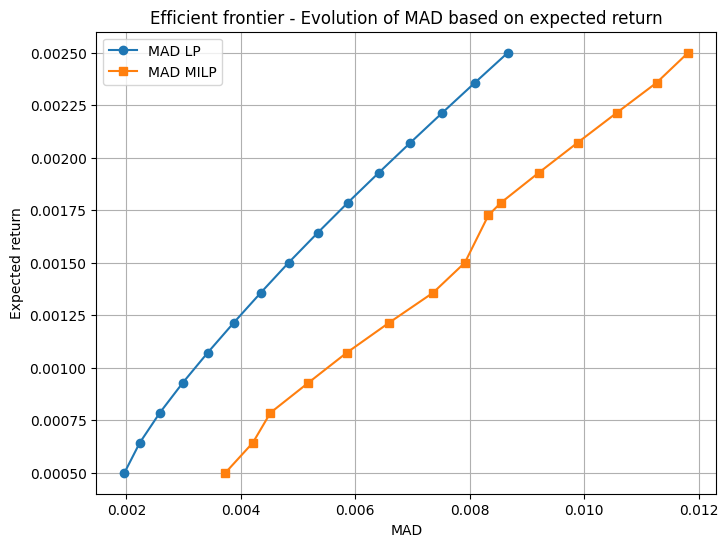


LP average adjacent weight variation : 0.1256
MILP average adjacent weight variation : 0.8782

Assets used per target return (MILP) : [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

Calculating weigth variance (LP) for 10 scenarios...
Weight variance (LP) for target return 0.0015 :

{'SPX': np.float64(0.00019896801463974568), 'AAPL': np.float64(0.001346312168538242), 'MSFT': np.float64(0.0009061260617798893), 'GOOG': np.float64(0.0015495754795664218), 'JPM': np.float64(0.0009016038234949906), 'XOM': np.float64(0.00017104241766210813), 'WMT': np.float64(0.0023403945070600953), 'TSLA': np.float64(0.00015806373408466432), 'UNH': np.float64(0.00042668415334327263), 'V': np.float64(0.0020687155613768526), 'NVDA': np.float64(0.0013237505060031546), 'DIS': np.float64(0.0), 'EFA': np.float64(0.0), 'VWO': np.float64(0.0), 'TM': np.float64(0.0), 'GLD': np.float64(0.0016167711938909074), 'USO': np.float64(8.349319727861034e-06), 'BND': np.float64(0.01148855201786026), 'VNQ': np.float64(0.0), 'UUP

In [6]:
import pandas as pd
import numpy as np
import pulp as pl
from typing import Dict, Optional
import matplotlib.pyplot as plt
from tqdm import tqdm


def compute_mad(returns: pd.DataFrame, w: np.ndarray) -> float:
    """
    Computes the Mean Average Deviation of the portfolio.

    Args : 
        returns (DataFrame) : all the returns from the assets.
        w (ndarray) : weights of the assets.
    
    Returns : 
        Mean Average Deviation of the portfolio.    
    """
    w = np.array(w)
        
    portfolio_returns = returns.values.dot(w)
    mean_return = portfolio_returns.mean()
    mad = np.mean(np.abs(portfolio_returns - mean_return))

    return mad

def optimize_mad_lp(returns: pd.DataFrame, target_return: float, lower_bounds: Optional[Dict[str, float]] = None, upper_bounds: Optional[Dict[str, float]] = None, allow_short: bool = False) -> Dict[str, float]:
    """
    This solves the linearized version of our problem. 
    
    Args:
        returns (DataFrame) : all the returns from the assets.
        target_return (float) : the minimum return we aim for.
        lower_bounds (Optional[Dict[str, float]]) : minimum weight per asset.
        upper_bounds (Optional[Dict[str, float]]) : maximum weight per asset.
        allow_short (bool) : True if we want to be able to short, False otherwise. 
        
    Returns:
        Dictionnary of optimal weights per asset -> {asset: weight}.
    """

    assets = list(returns.columns)
    T = len(returns)
    objective_function = pl.LpProblem("linear_portfolio_optimization", pl.LpMinimize)
    low_bound_w = None if allow_short else 0
    
    # Decision variables
    w = pl.LpVariable.dicts("w", assets, lowBound=low_bound_w)
    z = pl.LpVariable.dicts("z", list(range(T)), lowBound=0)
    mu_p = pl.LpVariable("mu_p")

    # Objective function
    objective_function += (1.0 / T) * pl.lpSum([z[i] for i in range(T)]), "objective_function"


    # --- CONSTRAINTS ---

    # mu_p
    mean_asset_returns = returns.mean(axis=0)
    objective_function += mu_p == pl.lpSum([mean_asset_returns[a] * w[a] for a in assets]), "mean_portfolio_return"

    # mad linearization
    for t, (_, return_values) in enumerate(returns.iterrows()):
        
        # R_p_t
        R_p_t = pl.lpSum([return_values[asset] * w[asset] for asset in assets])  
        
        # z_t : positive case
        objective_function += z[t] >= R_p_t - mu_p, f"mad_linearization_positive_case_{t}"
        
        # z_t : negative case
        objective_function += z[t] >= mu_p - R_p_t, f"mad_linearization_negative_case_{t}"

    # sum of weigths = 1
    objective_function += pl.lpSum([w[a] for a in assets]) == 1, "sum_of_weigths"
    
    # target return
    objective_function += mu_p >= target_return, "target_return"
    
    # min weigth
    if lower_bounds:
        for i, lower_bound in lower_bounds.items():
            if lower_bound < 0 and not allow_short:
                raise ValueError(f"Your lower bound '{lower_bound}' is negative. Shorting is not allowed here.")
            objective_function += w[i] >= lower_bound, f"lower_bound_{i}"
            
    # max weight
    if upper_bounds:
        for i, upper_bound in upper_bounds.items():
            objective_function += w[i] <= upper_bound, f"upper_bound_{i}"


    # solve
    objective_function.solve(pl.PULP_CBC_CMD(msg=False))
    status: str = pl.LpStatus[objective_function.status]

    if status != "Optimal":
        print(f"Warning ! Infeasible (status: {status}) for {target_return:.4f}.")
        return {a: 0.0 for a in assets}

    # optimal weights
    w_vals: Dict[str, float] = {
        a: w[a].value() if w[a].value() is not None else 0.0 
        for a in assets
    }
    
    return w_vals

def compute_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """
    Computes daily returns from prices.

    Args : 
        prices (DataFrame) : prices of the assets.
    
    Returns : 
        Dataframe of daily returns for each asset.
    """
    return prices.pct_change().dropna(how="all")

def clean_asset_file(file_path: str, ticker: str, parse_dates: bool = True, dayfirst: bool = True) -> pd.DataFrame:
    """
    Load an asset CSV file and clean it.

    Args : 
        file_path (str) : path of the CSV file.
        ticker (str) : ticker of the asset.
        parse_dates (bool) : True if should convert date column in datetime.
        dayfirst (bool) : True if DD/MM/YY, False otherwise.

    Returns : 
        Cleaned CSV file of dates/prices for the asset.
    """

    try:
        df = pd.read_csv(file_path, sep=None, engine="python", encoding="utf-8-sig", parse_dates=["Date"] if parse_dates else None, dayfirst=dayfirst)
    except FileNotFoundError:
        print(f"File {file_path} wasn't found.")
        return pd.DataFrame()
    except Exception as e:
        print(f"Error downloadinf {file_path} : {e}")
        return pd.DataFrame()

    price_col = df.columns[1] 
    df = df[["Date", price_col]].rename(columns={price_col: ticker})
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=dayfirst, errors='coerce')
    df = df.dropna(subset=["Date"])
    df = df.set_index("Date").sort_index()

    return df

def align_and_merge_prices(price_dfs: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    Merge and align asset price DataFrames.

    Args : 
        prices (Dict[str, pd.DataFrame]) : prices for each asset.

    Returns :    
        Merged and aligned asset price DataFrames.
    """
    
    if not price_dfs:
        return pd.DataFrame()

    first_ticker = next(iter(price_dfs))
    merged_df = price_dfs[first_ticker].reset_index().sort_values("Date")
    
    for ticker, ticker_df in price_dfs.items():
        if ticker != first_ticker:
            ticker_df = ticker_df.reset_index().sort_values("Date")
            merged_df = pd.merge_asof(merged_df, ticker_df, on="Date", direction="nearest", tolerance=pd.Timedelta(days=3))

    prices = merged_df.set_index("Date")
    prices = prices.dropna(how='any').sort_index() 

    return prices

def optimize_mad_milp(returns: pd.DataFrame, target_return: float, K: int = 3, lower_bound: float = 0.01, upper_bound: float = 0.5, allow_short: bool = False) -> Dict[str, float]:
    """
    This solves the new problem using MILP. 
    
    Args:
        returns (DataFrame) : all the returns from the assets.
        target_return (float) : the minimum return we aim for.
        lower_bound (float) : minimum weight for an asset.
        upper_bound (float]) : maximum weight for an asset.
        allow_short (bool) : True if we want to be able to short, False otherwise. 
        
    Returns:
        Dictionnary of optimal weights per asset -> {asset: weight}.
    """
    
    assets = list(returns.columns)
    T = len(returns)
    
    objective_function = pl.LpProblem("milp_portfolio_optimization", pl.LpMinimize)
    
    # Decision variables
    w = pl.LpVariable.dicts("w", assets, lowBound=None if allow_short else 0)
    z = pl.LpVariable.dicts("z", list(range(T)), lowBound=0)
    y = pl.LpVariable.dicts("y", assets, cat="Binary")  
    mu_p = pl.LpVariable("mu_p", lowBound=None)
    
    # Objective function
    objective_function += (1.0 / T) * pl.lpSum([z[t] for t in range(T)]), "MAD_obj"


    # --- CONSTRAINTS ---

    # mu_p
    mean_asset_returns = returns.mean()
    objective_function += mu_p == pl.lpSum([mean_asset_returns[a] * w[a] for a in assets]), "mu_def"
    
    # mad linearization
    for t, (_, return_values) in enumerate(returns.iterrows()):

        # R_p_t
        R_p_t = pl.lpSum([return_values[a] * w[a] for a in assets])

        # z_t : positive case
        objective_function += z[t] >= R_p_t - mu_p

        # z_t : negative case
        objective_function += z[t] >= mu_p - R_p_t
    
    # target return
    objective_function += mu_p >= target_return, "target_return"
    
    # sum of weights
    objective_function += pl.lpSum([w[a] for a in assets]) == 1, "sum_of_weights"
    
    # max weigth, min weigth
    for a in assets:
        objective_function += w[a] <= upper_bound * y[a]
        objective_function += w[a] >= lower_bound * y[a]
    
    # cardinality
    objective_function += pl.lpSum([y[a] for a in assets]) <= K, "cardinality"
    
    # Solve
    objective_function.solve(pl.PULP_CBC_CMD(msg=False))
    status: str = pl.LpStatus[objective_function.status]

    if status != "Optimal":
        print(f"Warning ! Infeasible (status: {status}) for {target_return:.4f}.")
        return {a: 0.0 for a in assets}
    
    # optimal weights
    w = {a: w[a].value() if w[a].value() else 0.0 for a in assets}
    y = {a: y[a].value() for a in assets}
    
    return w

# New functions

def efficient_frontier_lp(returns, target_returns, allow_short=False, lower_bounds=None, upper_bounds=None):
    """
    Computes the efficient frontier using LP.

    Args :
        returns (DataFrame) : all the returns from the assets.
        target_returns (List[float]) : minimum returns we aim for.       
        allow_short (bool) : True if we want to be able to short, False otherwise. 
        lower_bounds (Optional[Dict[str, float]]) : minimum weight per asset.
        upper_bounds (Optional[Dict[str, float]]) : maximum weight per asset.
    
    Returns :
        List of dictionnaries where each dictionnary represents a point on the efficient frontier. 
    """

    mad_evolution = []

    for target_return in tqdm(target_returns, desc="efficient_frontier_lp"):
        w = optimize_mad_lp(returns, target_return, lower_bounds=lower_bounds, upper_bounds=upper_bounds, allow_short=allow_short)
        w_array = np.array([w[a] for a in returns.columns])
        expected_return = float(np.dot(returns.mean(axis=0).values, w_array))
        mad = compute_mad(returns, w_array)
        mad_evolution.append({"target_return": target_return, "expected_return": expected_return, "mad": mad, "weights": w})

    return mad_evolution

def efficient_frontier_milp(returns, target_returns, K=3, lower_bounds=0.01, upper_bounds=0.5, allow_short=False):
    """
    Computes the efficient frontier using MILP.
    
    Args :
        returns (DataFrame) : all the returns from the assets.
        target_returns (List[float]) : minimum returns we aim for.       
        allow_short (bool) : True if we want to be able to short, False otherwise. 
        lower_bounds (Optional[Dict[str, float]]) : minimum weight per asset.
        upper_bounds (Optional[Dict[str, float]]) : maximum weight per asset.
    
    Returns :
        List of dictionnaries where each dictionnary represents a point on the efficient frontier. 
    """
    
    mad_evolution = []
    for target_return in tqdm(target_returns, desc="efficient_frontier_milp"):
        w = optimize_mad_milp(returns, target_return, K=K, lower_bound=lower_bounds, upper_bound=upper_bounds, allow_short=allow_short)
        w_array = np.array([w[a] for a in returns.columns])
        expected_return = float(np.dot(returns.mean(axis=0).values, w_array))
        mad = compute_mad(returns, w_array)
        mad_evolution.append({"target_return": target_return, "expected_return": expected_return, "mad": mad, "weights": w})

    return mad_evolution

def plot_efficient_frontiers(mad_evolution_lp, mad_evolution_milp=None):
    """
    Plots the 2 efficient frontiers.

    Args : 
        mad_evolution_milp (List[Dict]) : points of the efficient frontier using LP.
        mad_evolution_milp (List[Dict]) : points of the efficient frontier using MILP.
    
    Returns : 
        Plots the evolution of MAD based on expected return for LP and MILP.
    """

    plt.figure(figsize=(8,6))
    mad_lp = [r["mad"] for r in mad_evolution_lp]
    expected_return_lp = [r["expected_return"] for r in mad_evolution_lp]
    plt.plot(mad_lp, expected_return_lp, '-o', label="MAD LP")

    if mad_evolution_milp is not None:
        mad_milp = [r["mad"] for r in mad_evolution_milp]
        expected_return_milp = [r["expected_return"] for r in mad_evolution_milp]
        plt.plot(mad_milp, expected_return_milp, '-s', label="MAD MILP")

    plt.xlabel("MAD")
    plt.ylabel("Expected return")
    plt.title("Efficient frontier - Evolution of MAD based on expected return")
    plt.legend()
    plt.grid(True)
    plt.show()

def asset_weight_variation(points, tickers):
    """
    Compute average distance between adjacent frontier weights.

    Args : 
        points (List[Dict]) : points of the efficient frontier.
        tickers (List[str]) : asset names.

    Return : 
        Average distance between adjacent frontier weights and individual distances.
    """

    weights = [np.array([p["weights"][t] for t in tickers]) for p in points]
    distances = [np.sum(np.abs(weights[i+1] - weights[i])) for i in range(len(weights) - 1)]

    return np.mean(distances), distances

def count_assets(rows, threshold=1e-5):
    counts = [sum(1 for v in r["weights"].values() if abs(v) > threshold) for r in rows]
    return counts

def weight_variance(returns, target_return, number_of_bootstraps=100, solver="lp", milp_config=None):
    """
    Boostraps and re-solves to estimate weights variance.

    Args : 
        returns (DataFrame) : all the returns from the assets.
        target_return (float) : minimum return we aim for.       
        number_of_bootstraps (int) : number of bootstraps.
        solver ("lp" or "milp") : type of solver.
        milp_config (Dict) : MILP arguments if solver=="lp".

    Returns :
        Dictionnary of the assets and the bootstrap weight variance.
    """

    N = returns.shape[1]
    W = np.zeros((number_of_bootstraps, N))
    T = len(returns)    
    asset_names = list(returns.columns)

    for b in range(number_of_bootstraps):
        i = np.random.choice(T, size=T, replace=True)
        sample = returns.iloc[i]

        if solver == "lp":
            w = optimize_mad_lp(sample, target_return)
        else:
            config = milp_config or {}
            w = optimize_mad_milp(sample, target_return, K=config.get("K", 3),lower_bound=config.get("lower_bound", 0.01), upper_bound=config.get("upper_bound", 0.5))
        
        W[b, :] = np.array([w[a] for a in asset_names])

    variances = dict(zip(asset_names, W.var(axis=0)))

    return variances




if __name__ == "__main__":

    BASE_PATH = r"C:\Users\romsc\OneDrive - De Vinci\UVic\Courses\Optimization\Portfolio_Optimization"
    ASSETS = ["SPX", "AAPL", "MSFT", "GOOG", "JPM", "XOM", "WMT", "TSLA", "UNH", "V", "NVDA", "DIS", "EFA", "VWO", "TM", "GLD", "USO", "BND", "VNQ", "UUP"]

    dfs = {}
    for ticker in ASSETS:
        file_path = f"{BASE_PATH}\\{ticker}.csv"
        
        df = clean_asset_file(file_path, ticker)
        dfs[ticker] = df


    if len(dfs) != len(ASSETS):
        print("Error : Couldn't load 1 df per asset...")
        
    else:
        
        prices = align_and_merge_prices(dfs)
        returns = compute_returns(prices)
        mean_return = returns.mean().mean()
        target_returns = list(np.linspace(0.0005, 0.0025, 15))


        # frontiers
        lp_frontier = efficient_frontier_lp(returns, target_returns, allow_short=False)
        milp_K = 2
        milp_frontier = efficient_frontier_milp(returns, target_returns, K=milp_K, lower_bounds=0.05, upper_bounds=0.7, allow_short=False)

        plot_efficient_frontiers(lp_frontier, milp_frontier)


        # weight stability
        asset_names = list(returns.columns)
        lp_avg_dist, lp_dists = asset_weight_variation(lp_frontier, asset_names)
        milp_avg_dist, milp_dists = asset_weight_variation(milp_frontier, asset_names)
        lp_counts = count_assets(lp_frontier)
        milp_counts = count_assets(milp_frontier)

        print(f"\nLP average adjacent weight variation : {lp_avg_dist:.4f}")
        print(f"MILP average adjacent weight variation : {milp_avg_dist:.4f}\n")
        print("Assets used per target return (MILP) :", milp_counts)


        # weight variance
        target_for_bootstrap = target_returns[len(target_returns)//2]
        number_of_bootstraps = 10

        print(f"\nCalculating weigth variance (LP) for {number_of_bootstraps} scenarios...")
        weigth_variance_lp = weight_variance(returns, target_for_bootstrap, number_of_bootstraps=number_of_bootstraps, solver="lp")
        print(f"Weight variance (LP) for target return {target_for_bootstrap} :\n")
        print(weigth_variance_lp)

        print(f"\nCalculating weigth variance (MILP) for {number_of_bootstraps} scenarios...") 
        weigth_variance_milp = weight_variance(returns, target_for_bootstrap, number_of_bootstraps=number_of_bootstraps, solver="milp", milp_config={"K":milp_K, "lower_bound":0.05, "upper_bound":0.7})
        print(f"Weight variance (MILP) for target return {target_for_bootstrap} :\n")
        print(weigth_variance_milp)





# **NEXT STEPS !**

### 4. Dynamic rebalancing
We take the same model as before and make it rebalance dynamically with time. 
To introduce a time dimension, we go from our static portfolio : $$P = \sum_{i=1}^K w_i A_i \quad A_i \text{ being the } i \text{ asset}$$to its dynamic version : $$P_t = \sum_{i=1}^N w_{i,t} A_i$$
To simulate its historic performance, we backtest it using a rolling-window. What that means is that we re-optimize our portfolio at each time $t$ using the data of the last $T$ days. This allows us to maintain the lowest risk for the given target return.  

Obviously, dynamically rebalancing our portfolio means that we will modify our asset weights (called portfolio turnover), which implies transaction costs. These are generally expressed as a percentage of the turnover (quantity sold/bought). We include it using the following formulas : $$\text{Turnover}_t = \sum_{i=1}^N \big|w_{i,t} - w_{i,t-1}\big| \quad \text{ and } \quad \text{Cost}_t = r \cdot \text{Turnover}_t$$

# Stochastic Optimization

We take the same model as before and optimize it according to future returns. 

We go from optimizing only based on the past : $$\text{min } \frac{1}{T} \sum_{t=1}^{T} z_t$$to taking into account past and future returns : $$\min  
\mathbb{E} \left[ 
\frac{1}{T} \sum_{t=1}^{T} z_{t} \right]$$

$$\iff$$

$$\min  
\sum_{s=1}^{S} p_s \cdot  \left(
\frac{1}{T_s} \sum_{t=1}^{T_s} z_{s,t} \right)$$
Our methodology here is to do a Bootstrap process once again but this time we'll use it as for future returns. Since we sample randomly with replacement, we have $p_s = \frac{1}{B}$ for $B$ Bootstraps.

Therefore, we have :
$$\min  
\sum_{s=1}^{S} \frac{1}{B} \cdot  \left(
\frac{1}{T_s} \sum_{t=1}^{T_s} z_{s,t} \right) $$
$$ \text{s.t.} \quad \left\{ \begin{array}{ll} \sum_{i=1}^n w_i = 1 \\ \sum_{s=1}^S \frac{\mu_{p,s}}{B} \ge \mu_{\text{target}} \\ z_{s,t} \ge R_{p,t,s} - \mu_{p,s}, \quad \forall s, t \\ z_{s,t} \ge \mu_{p,s} - R_{p,t,s}, \quad \forall s, t \\ \\ w_i, z_{s,t} \ge 0 \end{array} \right. $$